# Experiment 4: Flipped-Problems Classifier (Causal Control)

| | |
|---|---|
| **Author** | Elad Moshe |
| **Supervisors** | Prof. Luciano Dyballa & Prof. Andrea Cremaschi |
| **Institution** | IE Madrid — MSc Computer Science |
| **Date** | June 2026 |
| **Priority** | MUST-HAVE — Causal Control |
| **Depends on** | `exp1_residual_stream_regression` (activations & labels) |
| **Optional** | `exp2_sae_decomposition` (SAE feature analysis in §9) |

> ---
> **AI Assistance Disclaimer:** Portions of this notebook (code scaffolding, documentation,
> and structural outlines) were generated with the assistance of Claude (Anthropic). All
> experimental design, interpretation, and conclusions are the author's own. AI-generated
> content has been reviewed and validated by the author before inclusion.
> ---

## Notebook Overview

**Research question:** Can logistic regression distinguish CoT from NoCoT residual-stream
activations *specifically on flipped problems* — those where CoT succeeds but NoCoT fails?
This is a causal control: restricting to the flipped subset eliminates problem difficulty
as a confound (both conditions see identical problems; only the presence/absence of
chain-of-thought differs).

### Experimental Design

| Parameter | Value |
|---|---|
| Dataset | GSM8K test set, n=400, seed=42 (inherited from Exp 1) |
| Flipped subset | CoT=correct AND NoCoT=incorrect (~40–60 problems) |
| Classification task | y=1 (CoT activations) vs y=0 (NoCoT activations) |
| Classifier | L2 LogReg, C=0.1, class_weight=balanced |
| CV scheme | 5-fold StratifiedGroupKFold (problem ID as group) |
| Bootstrap CI | n_boot=1000, percentile method |
| Primary metric | AUROC on aggregated CV held-out predictions |
| Layers tested | 6, 12, 18 |
| Positions tested | A (pre-answer token) · B (last prompt token) |

**Why StratifiedGroupKFold?** Each flipped problem contributes exactly one CoT and
one NoCoT activation. Using problem ID as group ensures both activations from the same
problem are always in the same fold — preventing cross-fold information leakage.

**Interpretation guide:**
- AUROC ≫ 0.5 at pos_a → residual stream encodes condition-specific structure precisely
  when CoT is causally decisive.
- AUROC ≈ 0.5 at pos_b → separation emerges *during* generation, not at prompt time.
- AUROC ≫ 0.5 at pos_b → a pre-existing bias already separates the two conditions
  before any reasoning tokens are written.

### Cache Files Produced

| File | Content |
|---|---|
| `cache/flipped_mask.npy` | Boolean (400,) mask: True where CoT=correct, NoCoT=wrong |
| `cache/flipped_row_ids.npy` | Integer indices of flipped problems |
| `cache/flipped_y.npy` | Labels: 1=CoT, 0=NoCoT (length 2·n_flip) |
| `cache/flipped_groups.npy` | Problem index repeated twice (for grouped CV) |
| `cache/flipped_X_{pos}_layer{L}.npy` | Stacked activations (2·n_flip, 2304) per combo |
| `cache/flipped_lr_results.csv` | AUROC ± std, CI, p-value per (pos × layer) |
| `cache/cv_predictions_{pos}_layer{L}.npz` | y_true, y_score from aggregated CV folds |
| `cache/bootstrap_distributions.npz` | 1000-sample AUROC distributions (all combos) |
| `cache/flipped_summary.json` | All key numbers for thesis reporting |
| `figures/fig1_roc_curve.png` | ROC curve + bootstrap CI band (primary metric) |
| `figures/fig2_auroc_grid.png` | AUROC by layer × position with CI error bars |
| `figures/fig3_pca_scatter.png` | PCA-2D scatter: CoT vs NoCoT on flipped problems |
| `figures/fig4_sae_top_features.png` | Top SAE features (only if Exp 2 cache exists) |

## Installation

**Run once, then restart the session** (`Runtime → Restart session`).

> Exp 4 does **not** load Gemma-2-2B. All activations come from Exp 1's cache.
> `sae-lens` is only needed for the optional SAE feature analysis in §9.

In [1]:
# Run once, then Runtime → Restart session.
import subprocess, sys

subprocess.run(
    [sys.executable, '-m', 'pip', 'uninstall', '-y', 'torchvision', 'torchaudio'],
    capture_output=True,
)
subprocess.run([
    sys.executable, '-m', 'pip', 'install', '-q',
    'scikit-learn>=1.3',
    'pyarrow',
    'numpy>=1.24',
    'pandas',
    'matplotlib',
    'tqdm',
    'sae-lens>=3.0.0',    # optional — §9 SAE feature analysis only
], check=True)

print('Packages installed.')
print('>>> Runtime → Restart session, then run from §0. <<<')

Packages installed.
>>> Runtime → Restart session, then run from §0. <<<


## 0. Mount Google Drive

**Run first on every session.** Mounts Drive and auto-detects this notebook's
folder, then sets `CACHE_DIR`, `FIGURES_DIR`, `EXP1_CACHE`, and `EXP2_CACHE` —
all pointing to persistent Drive storage under `backup/`.

Nothing is written to Colab's ephemeral `/content/` filesystem.

In [2]:
from google.colab import drive
from pathlib import Path
import subprocess

drive.mount('/content/drive')

# ── Auto-detect this notebook's folder in Drive ───────────────────────────
# Strategy 1 (fast): walk one level under MyDrive — catches shortcuts directly.
# Strategy 2 (fallback): find -L to follow symlinks inside Computers.
def _find_notebook_dir(name: str) -> Path:
    my_drive = Path('/content/drive/MyDrive')
    if my_drive.exists():
        top = sorted(d for d in my_drive.iterdir() if d.is_dir())
        print(f'  MyDrive entries: {[d.name for d in top]}')
        for entry in top:
            if entry.name == name:
                return entry
            candidate = entry / name
            if candidate.exists():
                return candidate
    else:
        print('  /content/drive/MyDrive not found — check Drive mount.')
    roots = ([str(my_drive)] if my_drive.exists() else [])
    computers = Path('/content/drive/Computers')
    if computers.exists():
        roots.append(str(computers))
    for root in roots:
        print(f'  Falling back to find -L in {Path(root).name}...')
        r = subprocess.run(
            ['find', '-L', root, '-maxdepth', '20', '-type', 'd', '-name', name],
            capture_output=True, text=True, timeout=240,
        )
        hits = [p.strip() for p in r.stdout.strip().split('\n')
                if p.strip() and '/backup' not in p and '/.Trash' not in p]
        if hits:
            return Path(hits[0])
    top_names = ([d.name for d in my_drive.iterdir()] if my_drive.exists() else [])
    raise RuntimeError(
        f'Could not find "{name}" in Drive.\n'
        f'  MyDrive contents: {top_names}\n\n'
        'To fix — pick ONE option:\n'
        '  A) Shortcut: drive.google.com → find the "experiments" folder\n'
        '     → Right-click → Organize → Add shortcut → My Drive\n'
        '     Then re-run this cell.\n\n'
        '  B) Manual override — add this line BEFORE the _find_notebook_dir() call:\n'
        '     NOTEBOOK_DIR = Path("/content/drive/MyDrive/<folder_in_list_above>/exp4_flipped_problems_classifier")\n'
        '     (use the MyDrive contents list above to find the right parent folder)'
    )


print('Auto-detecting notebook folder in Drive...')
NOTEBOOK_DIR = _find_notebook_dir('exp4_flipped_problems_classifier')

BACKUP_DIR  = NOTEBOOK_DIR / 'backup'
CACHE_DIR   = BACKUP_DIR / 'cache'
FIGURES_DIR = BACKUP_DIR / 'figures'

# Exp1 activations — try canonical path first, fall back to old location
_exp1_new = NOTEBOOK_DIR.parent / 'exp1_residual_stream_regression' / 'backup' / 'cache'
_exp1_old = Path('/content/drive/MyDrive/exp1_cache')
if _exp1_new.exists():
    EXP1_CACHE = _exp1_new
elif _exp1_old.exists():
    print(f'  exp1 cache found at old location: {_exp1_old}')
    print(f'  (Run exp1 migration cell to move to canonical path — optional)')
    EXP1_CACHE = _exp1_old
else:
    EXP1_CACHE = _exp1_new

# Exp2 SAE decomposition cache (optional — §9 SAE section only)
EXP2_CACHE = NOTEBOOK_DIR.parent / 'exp2_sae_decomposition' / 'backup' / 'cache'

CACHE_DIR.mkdir(parents=True, exist_ok=True)
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

print('Drive ready.')
print(f'  Notebook:        {NOTEBOOK_DIR}')
print(f'  Backup/cache:    {CACHE_DIR}')
print(f'  Backup/figures:  {FIGURES_DIR}')
print(f'  Exp1 cache:      {EXP1_CACHE}  -> {"EXISTS" if EXP1_CACHE.exists() else "MISSING — run exp1 first"}')
print(f'  Exp2 cache:      {EXP2_CACHE}  -> {"exists (SAE available)" if EXP2_CACHE.exists() else "not found (SAE section will be skipped)"}')

Mounted at /content/drive
Auto-detecting notebook folder in Drive...
  MyDrive entries: ['Colab Notebooks', 'Elad Moshe - MSc in CS', 'Research Capstone - Elad (LLM Reasoning)', 'University', 'exp1_cache', 'exp1_figures', 'experiments', 'h1_checkpoints', 'h1_runs', 'research capstone', 'אלעד משה - תואר שני', 'אלעד משה - תואר שני (1)', 'דרייב מחו"ג', 'כספות', 'מדמ"ח', 'מדעי המחשב', 'מדעי המחשב ישן ', 'מעבדות עותק', 'מעבדות פיזיקה אלעד משה', 'מערכות הפעלה', 'מערכות הפעלה (1)', 'סרטים להגות צבאית', 'פייתון תיכון', 'רב תחומי', 'שנה שלישית - חבצלות', 'תיק השקעות', 'תיקיית יב - תמונות']
  exp1 cache found at old location: /content/drive/MyDrive/exp1_cache
  (Run exp1 migration cell to move to canonical path — optional)
Drive ready.
  Notebook:        /content/drive/MyDrive/experiments/exp4_flipped_problems_classifier
  Backup/cache:    /content/drive/MyDrive/experiments/exp4_flipped_problems_classifier/backup/cache
  Backup/figures:  /content/drive/MyDrive/experiments/exp4_flipped_problems_c

## 0b. Setup & Imports

Run after the Drive mount cell. Imports libraries, sets constants, and verifies
that all path variables point to Drive.

In [3]:
# ── Neutralise Colab binary conflicts ────────────────────────────────────
import sys, importlib.util, os, json, warnings

def _neutralise(pkg):
    try:
        __import__(pkg)
    except (OSError, ImportError):
        for key in list(sys.modules.keys()):
            if key == pkg or key.startswith(pkg + '.'):
                del sys.modules[key]
        _orig = importlib.util.find_spec
        def _patched(name, *a, **kw):
            if name == pkg or name.startswith(pkg + '.'):
                return None
            return _orig(name, *a, **kw)
        importlib.util.find_spec = _patched

_neutralise('torchaudio')
_neutralise('torchvision')
warnings.filterwarnings('ignore')

# ── Standard imports ─────────────────────────────────────────────────────
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from matplotlib.patches import Patch
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedGroupKFold
from sklearn.metrics import roc_auc_score, roc_curve
from sklearn.decomposition import PCA

# ── Constants ─────────────────────────────────────────────────────────────
SEED          = 42
LAYERS        = [6, 12, 18]
POSITIONS     = ['pos_a', 'pos_b']
N_BOOT        = 1000
LR_C          = 0.1
LR_FOLDS      = 5
HIDDEN_DIM    = 2304
N_SAE_FEATS   = 16384
SAE_LAYER     = 12

PRIMARY_POS   = 'pos_a'
PRIMARY_LAYER = 12

np.random.seed(SEED)

# ── Verify Drive paths are set correctly ──────────────────────────────────
# CACHE_DIR, FIGURES_DIR, EXP1_CACHE, EXP2_CACHE must be defined by the
# Drive mount cell (§0). This guard catches running cells out of order.
for _var, _val in [('CACHE_DIR',   CACHE_DIR),
                   ('FIGURES_DIR', FIGURES_DIR),
                   ('EXP1_CACHE',  EXP1_CACHE),
                   ('EXP2_CACHE',  EXP2_CACHE)]:
    assert '/content/drive/' in str(_val), (
        f'{_var} does not point to Google Drive: {_val}\n'
        'Run the Drive mount cell (§0) before this cell.'
    )

print('Setup complete.')
print(f'  Cache:    {CACHE_DIR}')
print(f'  Figures:  {FIGURES_DIR}')


Setup complete.
  Cache:    /content/drive/MyDrive/experiments/exp4_flipped_problems_classifier/backup/cache
  Figures:  /content/drive/MyDrive/experiments/exp4_flipped_problems_classifier/backup/figures


## 1. Load Labels & Activations from Exp 1

Loads correctness labels and pre-computed residual-stream activations from
`exp1_residual_stream_regression`. **No new forward passes are performed here.**

| File | Shape | Source |
|---|---|---|
| `responses_cot.parquet` | (400, *) | Exp 1 generation |
| `responses_nocot.parquet` | (400, *) | Exp 1 generation |
| `acts_{cond}_{pos}_layer{L}.npy` | (400, 2304) | Exp 1 activation capture |

> If Exp 1 has not been run, the assert below halts with a clear message.

In [4]:
assert EXP1_CACHE.exists(), (
    f'Exp 1 cache not found at {EXP1_CACHE.resolve()}.\n'
    'Please run exp1_residual_stream_regression first to generate activations.'
)

# ── Correctness labels ────────────────────────────────────────────────────
df_cot   = pd.read_parquet(EXP1_CACHE / 'responses_cot.parquet')
df_nocot = pd.read_parquet(EXP1_CACHE / 'responses_nocot.parquet')

y_cot   = df_cot['correct'].astype(int).values    # (400,)
y_nocot = df_nocot['correct'].astype(int).values

acc_cot   = df_cot['correct'].mean()
acc_nocot = df_nocot['correct'].mean()

print('=' * 55)
print('  EXP 1 SUMMARY')
print('=' * 55)
print(f'  Problems loaded:  {len(df_cot)}')
print(f'  CoT accuracy:     {acc_cot:.1%}  ({int(y_cot.sum())}/{len(y_cot)})')
print(f'  NoCoT accuracy:   {acc_nocot:.1%}  ({int(y_nocot.sum())}/{len(y_nocot)})')
print('=' * 55)

# ── Activation arrays ─────────────────────────────────────────────────────
# raw_acts[(cond, pos, layer)] -> np.ndarray (400, 2304)
raw_acts = {}
for cond in ('cot', 'nocot'):
    for pos in POSITIONS:
        for layer in LAYERS:
            p = EXP1_CACHE / f'acts_{cond}_{pos}_layer{layer}.npy'
            assert p.exists(), f'Missing activation cache: {p}'
            raw_acts[(cond, pos, layer)] = np.load(p)

n_arrays = len(raw_acts)
sample_shape = next(iter(raw_acts.values())).shape
print(f'\nLoaded {n_arrays} activation arrays, each shape {sample_shape}.')
print('Keys: (condition, position, layer)')

  EXP 1 SUMMARY
  Problems loaded:  400
  CoT accuracy:     51.0%  (204/400)
  NoCoT accuracy:   8.0%  (32/400)

Loaded 12 activation arrays, each shape (400, 2304).
Keys: (condition, position, layer)


## 2. Identify Flipped Problems

A problem is **flipped** when CoT produces the correct answer and NoCoT does not.
These are the problems where chain-of-thought prompting is *causally decisive*.

**Expected count:** ~40–60 problems (≈10–15% of 400), based on the CoT–NoCoT
accuracy gap observed in Exp 1.

The 2×2 contingency table below shows the full cross-classification.

**Cache:** `cache/flipped_mask.npy`, `cache/flipped_row_ids.npy`

In [5]:
MASK_CACHE     = CACHE_DIR / 'flipped_mask.npy'
FLIP_IDS_CACHE = CACHE_DIR / 'flipped_row_ids.npy'

if MASK_CACHE.exists() and FLIP_IDS_CACHE.exists():
    flipped_mask = np.load(MASK_CACHE)
    flipped_ids  = np.load(FLIP_IDS_CACHE)
    print('Flipped mask loaded from cache.')
else:
    cot_corr   = df_cot['correct'].values
    nocot_corr = df_nocot['correct'].values
    flipped_mask = cot_corr & ~nocot_corr     # CoT=True AND NoCoT=False
    flipped_ids  = np.where(flipped_mask)[0]
    np.save(MASK_CACHE,     flipped_mask)
    np.save(FLIP_IDS_CACHE, flipped_ids)
    print('Flipped mask computed and saved.')

n_flip  = int(flipped_mask.sum())
n_total = len(flipped_mask)

# Recompute cross-classification from loaded labels (always fresh for display)
c_corr  = df_cot['correct'].values
nc_corr = df_nocot['correct'].values

both_correct   = int((c_corr  &  nc_corr).sum())
flipped_count  = int((c_corr  & ~nc_corr).sum())   # CoT better
anti_flip      = int((~c_corr &  nc_corr).sum())   # NoCoT better
both_wrong     = int((~c_corr & ~nc_corr).sum())

print(f'\n{"=" * 55}')
print('  2x2 CONTINGENCY TABLE')
print(f'{"=" * 55}')
print(f'  {"":25s}  CoT=True  CoT=False')
print(f'  {"NoCoT=True":25s}  {both_correct:8d}  {anti_flip:9d}')
print(f'  {"NoCoT=False":25s}  {flipped_count:8d}  {both_wrong:9d}')
print(f'{"=" * 55}')
print(f'  Flipped (CoT=True, NoCoT=False):  {flipped_count}  ({flipped_count/n_total:.1%})')
print(f'  Anti-flip (CoT=False, NoCoT=True): {anti_flip}  ({anti_flip/n_total:.1%})')
print(f'{"=" * 55}')
print(f'\n  Classifier data points:  {n_flip} CoT + {n_flip} NoCoT = {2*n_flip} total')
print(f'  Approx fold size:        ~{2*n_flip // LR_FOLDS} per fold ({LR_FOLDS}-fold CV)')

Flipped mask computed and saved.

  2x2 CONTINGENCY TABLE
                             CoT=True  CoT=False
  NoCoT=True                       18         14
  NoCoT=False                     186        182
  Flipped (CoT=True, NoCoT=False):  186  (46.5%)
  Anti-flip (CoT=False, NoCoT=True): 14  (3.5%)

  Classifier data points:  186 CoT + 186 NoCoT = 372 total
  Approx fold size:        ~74 per fold (5-fold CV)


## 3. Stack Paired Activations

For each (position × layer) combination, extracts activations at the flipped-problem
indices and stacks them into a paired design matrix:

```
X[0 .. n_flip-1]       = CoT   activations at flipped problems   → y = 1
X[n_flip .. 2*n_flip-1] = NoCoT activations at flipped problems   → y = 0
groups[0 .. 2*n_flip-1] = problem index (0..n_flip-1, repeated twice)
```

The `groups` vector ensures `StratifiedGroupKFold` keeps both conditions for the same
problem in the same CV fold, preventing look-ahead bias from correlated activations.

**Cache:**
- `cache/flipped_y.npy` — labels (length 2·n_flip)
- `cache/flipped_groups.npy` — group indices (length 2·n_flip)
- `cache/flipped_X_{pos}_layer{L}.npy` — stacked activations per combo

In [6]:
Y_CACHE      = CACHE_DIR / 'flipped_y.npy'
GROUPS_CACHE = CACHE_DIR / 'flipped_groups.npy'

# Labels and groups are identical for all (pos, layer) combos
if Y_CACHE.exists() and GROUPS_CACHE.exists():
    y_flip      = np.load(Y_CACHE)
    groups_flip = np.load(GROUPS_CACHE)
    print('Labels and group indices loaded from cache.')
else:
    y_flip      = np.concatenate([
        np.ones(n_flip,  dtype=np.int32),   # CoT  = 1
        np.zeros(n_flip, dtype=np.int32),   # NoCoT = 0
    ])
    # Same problem ID for the CoT and NoCoT rows — keeps pairs in same fold
    groups_flip = np.concatenate([np.arange(n_flip), np.arange(n_flip)])
    np.save(Y_CACHE,      y_flip)
    np.save(GROUPS_CACHE, groups_flip)
    print('Labels and group indices computed and saved.')

# Stack activation arrays for each (pos, layer) combo
stacked_acts = {}

for pos in POSITIONS:
    for layer in LAYERS:
        X_cache = CACHE_DIR / f'flipped_X_{pos}_layer{layer}.npy'
        if X_cache.exists():
            stacked_acts[(pos, layer)] = np.load(X_cache)
            print(f'  [{pos}  L{layer:2d}] Loaded from cache.')
        else:
            X_cot   = raw_acts[('cot',   pos, layer)][flipped_mask]  # (n_flip, dim)
            X_nocot = raw_acts[('nocot', pos, layer)][flipped_mask]  # (n_flip, dim)
            X_stk   = np.vstack([X_cot, X_nocot])                    # (2*n_flip, dim)
            stacked_acts[(pos, layer)] = X_stk
            np.save(X_cache, X_stk)
            print(f'  [{pos}  L{layer:2d}] Stacked {X_stk.shape} -> saved.')

print(f'\nAll stacked arrays ready.')
print(f'  y_flip shape:      {y_flip.shape}   classes={np.unique(y_flip).tolist()}')
print(f'  groups_flip shape: {groups_flip.shape}   unique groups={len(np.unique(groups_flip))}')
print(f'  Each X array:      ({2*n_flip}, {HIDDEN_DIM})')

Labels and group indices computed and saved.
  [pos_a  L 6] Stacked (372, 2304) -> saved.
  [pos_a  L12] Stacked (372, 2304) -> saved.
  [pos_a  L18] Stacked (372, 2304) -> saved.
  [pos_b  L 6] Stacked (372, 2304) -> saved.
  [pos_b  L12] Stacked (372, 2304) -> saved.
  [pos_b  L18] Stacked (372, 2304) -> saved.

All stacked arrays ready.
  y_flip shape:      (372,)   classes=[0, 1]
  groups_flip shape: (372,)   unique groups=186
  Each X array:      (372, 2304)


## 4. Cross-Validated AUROC — All Layers × Positions

Fits an L2 logistic regression under 5-fold `StratifiedGroupKFold` CV for every
(position × layer) combination. Predictions from all held-out folds are concatenated
to compute a single aggregate AUROC.

**Key design choice — grouped CV:** `StratifiedGroupKFold` with `groups=problem_id`
ensures that both the CoT and NoCoT activation from the same problem always land in
the same fold. Without this, correlated activations for the same problem could leak
across train/test and inflate AUROC.

**Saved:**
- `cache/flipped_lr_results.csv` — point estimates per combo
- `cache/cv_predictions_{pos}_layer{L}.npz` — held-out (y_true, y_score) per combo

In [7]:
LR_RESULTS_CACHE = CACHE_DIR / 'flipped_lr_results.csv'


def run_grouped_cv(X, y, groups, C=LR_C, n_splits=LR_FOLDS, seed=SEED):
    """5-fold StratifiedGroupKFold LR. Returns (overall_auroc, fold_aurocs, y_true, y_score)."""
    lr = LogisticRegression(
        C=C, class_weight='balanced',
        max_iter=2000, solver='lbfgs', random_state=seed,
    )
    cv = StratifiedGroupKFold(n_splits=n_splits)
    y_true_all, y_score_all, fold_aurocs = [], [], []

    for tr_idx, te_idx in cv.split(X, y, groups=groups):
        X_tr, X_te = X[tr_idx], X[te_idx]
        y_tr, y_te = y[tr_idx], y[te_idx]
        if len(np.unique(y_tr)) < 2 or len(np.unique(y_te)) < 2:
            continue
        lr.fit(X_tr, y_tr)
        proba = lr.predict_proba(X_te)[:, 1]
        fold_aurocs.append(roc_auc_score(y_te, proba))
        y_true_all.extend(y_te.tolist())
        y_score_all.extend(proba.tolist())

    y_true  = np.array(y_true_all)
    y_score = np.array(y_score_all)
    overall = roc_auc_score(y_true, y_score) if len(y_true) > 0 else float('nan')
    return overall, fold_aurocs, y_true, y_score


# ── Reload any per-combo CV predictions already on disk ──────────────────
cv_preds = {}
for pos in POSITIONS:
    for layer in LAYERS:
        p = CACHE_DIR / f'cv_predictions_{pos}_layer{layer}.npz'
        if p.exists():
            npz = np.load(p)
            cv_preds[(pos, layer)] = (npz['y_true'], npz['y_score'])

# ── Identify which combos are already in the results CSV ─────────────────
if LR_RESULTS_CACHE.exists():
    df_lr     = pd.read_csv(LR_RESULTS_CACHE)
    done_keys = {(r.position, int(r.layer)) for _, r in df_lr.iterrows()}
    print(f'Existing results: {len(df_lr)} / {len(POSITIONS)*len(LAYERS)} combos cached.')
else:
    df_lr     = pd.DataFrame()
    done_keys = set()

# ── Run missing combos — save after EACH one (crash loses at most one step) ──
needs_run = [
    (pos, layer) for pos in POSITIONS for layer in LAYERS
    if (pos, layer) not in done_keys or (pos, layer) not in cv_preds
]

if not needs_run:
    print('All combos already cached.')
else:
    print(f'Running {len(needs_run)} / {len(POSITIONS)*len(LAYERS)} missing combo(s)...')
    for pos, layer in needs_run:
        X = stacked_acts[(pos, layer)]
        auroc, fold_aurocs, y_true, y_score = run_grouped_cv(X, y_flip, groups_flip)

        # Step 1: save CV predictions immediately — safest recovery checkpoint
        pred_cache = CACHE_DIR / f'cv_predictions_{pos}_layer{layer}.npz'
        np.savez(pred_cache, y_true=y_true, y_score=y_score)
        cv_preds[(pos, layer)] = (y_true, y_score)

        # Step 2: append row to CSV immediately — partial progress survives a crash
        new_row = pd.DataFrame([{
            'position':  pos,
            'layer':     layer,
            'auroc':     round(auroc, 4),
            'auroc_std': round(float(np.std(fold_aurocs)), 4) if fold_aurocs else float('nan'),
            'n_folds':   len(fold_aurocs),
            'n_samples': int(len(X)),
        }])
        df_lr = pd.concat([df_lr, new_row], ignore_index=True)
        df_lr.to_csv(LR_RESULTS_CACHE, index=False)

        folds_str = '  '.join(f'{v:.3f}' for v in fold_aurocs)
        print(f'  [{pos}  L{layer:2d}]  AUROC={auroc:.4f}  std={np.std(fold_aurocs):.4f}')
        print(f'              folds: [{folds_str}]  -> saved')

# Always reload CSV so df_lr reflects the complete set of combos
df_lr = pd.read_csv(LR_RESULTS_CACHE)
print(f'\nAll {len(df_lr)} / {len(POSITIONS)*len(LAYERS)} combos complete.')
print('\n=== CV AUROC RESULTS (CoT vs NoCoT on flipped problems) ===')
pivot = df_lr.pivot_table(index='layer', columns='position', values='auroc')
print(pivot.to_string())
print('\nShuffle baseline (expected): ~0.5000')


Running 6 / 6 missing combo(s)...
  [pos_a  L 6]  AUROC=1.0000  std=0.0000
              folds: [1.000  1.000  1.000  1.000  1.000]  -> saved
  [pos_a  L12]  AUROC=1.0000  std=0.0000
              folds: [1.000  1.000  1.000  1.000  1.000]  -> saved
  [pos_a  L18]  AUROC=1.0000  std=0.0000
              folds: [1.000  1.000  1.000  1.000  1.000]  -> saved
  [pos_b  L 6]  AUROC=1.0000  std=0.0000
              folds: [1.000  1.000  1.000  1.000  1.000]  -> saved
  [pos_b  L12]  AUROC=1.0000  std=0.0000
              folds: [1.000  1.000  1.000  1.000  1.000]  -> saved
  [pos_b  L18]  AUROC=1.0000  std=0.0000
              folds: [1.000  1.000  1.000  1.000  1.000]  -> saved

All 6 / 6 combos complete.

=== CV AUROC RESULTS (CoT vs NoCoT on flipped problems) ===
position  pos_a  pos_b
layer                 
6           1.0    1.0
12          1.0    1.0
18          1.0    1.0

Shuffle baseline (expected): ~0.5000


## 5. Bootstrap Confidence Intervals

Computes 95% bootstrap confidence intervals (percentile method, n_boot=1000)
for the AUROC at every (position × layer) combination.

**Method:** Resamples the aggregated CV held-out predictions (y_true, y_score) with
replacement and recomputes AUROC on each resample. The 2.5th and 97.5th percentiles
form the 95% CI. Since the predictions are from held-out CV folds, the CI is around
the *out-of-sample* AUROC estimate.

**Empirical p-value:** Fraction of bootstrap samples with AUROC ≤ 0.50 estimates the
one-sided probability that the true AUROC equals chance (H₀: AUROC = 0.5).

**Saved:** `cache/bootstrap_distributions.npz`  
Updated: `cache/flipped_lr_results.csv` (adds ci_lo, ci_hi, p_vs_chance columns)

In [8]:
BOOT_CACHE = CACHE_DIR / 'bootstrap_distributions.npz'


def bootstrap_ci(y_true, y_score, n_boot=N_BOOT, seed=SEED):
    """Percentile bootstrap CI for AUROC from held-out CV predictions.

    Returns (ci_lo, ci_hi, boot_array).
    """
    rng = np.random.default_rng(seed)
    n   = len(y_true)
    boot_aurocs = []
    for _ in range(n_boot):
        idx = rng.integers(0, n, size=n)
        y_b, s_b = y_true[idx], y_score[idx]
        if len(np.unique(y_b)) < 2:
            continue
        try:
            boot_aurocs.append(roc_auc_score(y_b, s_b))
        except ValueError:
            pass
    arr = np.array(boot_aurocs)
    ci_lo, ci_hi = np.percentile(arr, [2.5, 97.5])
    return float(ci_lo), float(ci_hi), arr


# ── Per-combo .npy files written immediately: crash mid-loop loses only current combo ─
boot_dists = {}
print(f'Bootstrap CI  (n_boot={N_BOOT})  —  checking per-combo cache...')

for pos in POSITIONS:
    for layer in LAYERS:
        per_cache = CACHE_DIR / f'bootstrap_{pos}_layer{layer}.npy'

        if per_cache.exists():
            dist = np.load(per_cache)
            boot_dists[(pos, layer)] = dist
            ci_lo, ci_hi = np.percentile(dist, [2.5, 97.5])
            auroc_pt = df_lr.loc[
                (df_lr.position == pos) & (df_lr.layer == layer), 'auroc'
            ].values[0]
            print(f'  [{pos}  L{layer:2d}] Cached    {auroc_pt:.4f}  [{ci_lo:.4f}, {ci_hi:.4f}]')
        else:
            y_true_cv, y_score_cv = cv_preds[(pos, layer)]
            ci_lo, ci_hi, dist = bootstrap_ci(y_true_cv, y_score_cv)
            boot_dists[(pos, layer)] = dist
            np.save(per_cache, dist)   # save immediately after this combo
            auroc_pt = df_lr.loc[
                (df_lr.position == pos) & (df_lr.layer == layer), 'auroc'
            ].values[0]
            print(f'  [{pos}  L{layer:2d}] Computed  {auroc_pt:.4f}  [{ci_lo:.4f}, {ci_hi:.4f}]  -> saved')

# Consolidate per-combo files into one .npz for downstream code compatibility
np.savez(BOOT_CACHE, **{
    f'{pos}_layer{layer}': boot_dists[(pos, layer)]
    for pos in POSITIONS for layer in LAYERS
})
print(f'\nConsolidated -> {BOOT_CACHE}')

# ── Merge CI stats into df_lr_full and re-save CSV ───────────────────────
ci_rows = []
for pos in POSITIONS:
    for layer in LAYERS:
        dist = boot_dists[(pos, layer)]
        ci_lo, ci_hi = np.percentile(dist, [2.5, 97.5])
        p_val = float((dist <= 0.5).mean())   # one-sided p-value vs H0: AUROC=0.5
        ci_rows.append({'position': pos, 'layer': layer,
                        'ci_lo': round(float(ci_lo), 4),
                        'ci_hi': round(float(ci_hi), 4),
                        'p_vs_chance': round(p_val, 4)})

df_ci      = pd.DataFrame(ci_rows)
df_lr_full = df_lr.merge(df_ci, on=['position', 'layer'], how='left')
df_lr_full.to_csv(LR_RESULTS_CACHE, index=False)

print('\n=== AUROC WITH 95% BOOTSTRAP CI ===')
print(f'{"":10s} {"Layer":>6} {"AUROC":>8} {"95% CI":>20} {"p (vs 0.5)":>12}')
print('-' * 62)
for _, row in df_lr_full.sort_values(['position', 'layer']).iterrows():
    marker = ' <-- PRIMARY' if (row.position == PRIMARY_POS and row.layer == PRIMARY_LAYER) else ''
    ci_str = f'[{row.ci_lo:.4f}, {row.ci_hi:.4f}]'
    print(f'{row.position:<10} {row.layer:>6} {row.auroc:>8.4f} {ci_str:>20} {row.p_vs_chance:>12.4f}{marker}')
print(f'\nResults saved -> {LR_RESULTS_CACHE}')


Bootstrap CI  (n_boot=1000)  —  checking per-combo cache...
  [pos_a  L 6] Computed  1.0000  [1.0000, 1.0000]  -> saved
  [pos_a  L12] Computed  1.0000  [1.0000, 1.0000]  -> saved
  [pos_a  L18] Computed  1.0000  [1.0000, 1.0000]  -> saved
  [pos_b  L 6] Computed  1.0000  [1.0000, 1.0000]  -> saved
  [pos_b  L12] Computed  1.0000  [1.0000, 1.0000]  -> saved
  [pos_b  L18] Computed  1.0000  [1.0000, 1.0000]  -> saved

Consolidated -> /content/drive/MyDrive/experiments/exp4_flipped_problems_classifier/backup/cache/bootstrap_distributions.npz

=== AUROC WITH 95% BOOTSTRAP CI ===
            Layer    AUROC               95% CI   p (vs 0.5)
--------------------------------------------------------------
pos_a           6   1.0000     [1.0000, 1.0000]       0.0000
pos_a          12   1.0000     [1.0000, 1.0000]       0.0000 <-- PRIMARY
pos_a          18   1.0000     [1.0000, 1.0000]       0.0000
pos_b           6   1.0000     [1.0000, 1.0000]       0.0000
pos_b          12   1.0000     [1.000

## 6. Figure 1 — ROC Curve with Bootstrap CI Band

Plots the ROC curve for the primary metric (Position A, Layer 12) using the
aggregated CV held-out predictions. A 95% bootstrap confidence band is drawn by
interpolating 500 bootstrap ROC curves at a fixed FPR grid and shading between
the 2.5th and 97.5th percentiles.

**Why pos_a, layer 12?**
- Position A captures the model state after the full reasoning chain is written
  (the last generated token before the answer delimeter).
- Layer 12 is the SAE-instrumented layer (Gemma Scope canonical) used throughout.

**Saved:** `figures/fig1_roc_curve.png`

Saved: /content/drive/MyDrive/experiments/exp4_flipped_problems_classifier/backup/figures/fig1_roc_curve.png


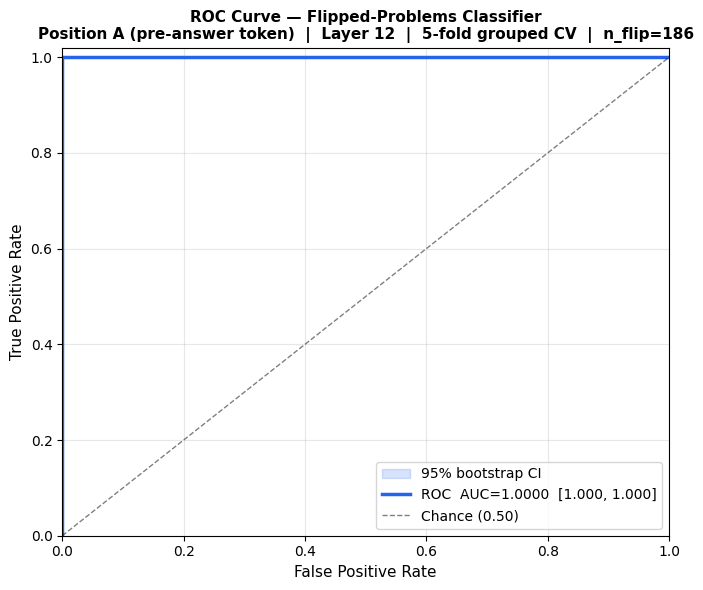

In [9]:
ROC_FIG = FIGURES_DIR / 'fig1_roc_curve.png'


def build_bootstrap_roc_band(y_true, y_score, n_boot=500, seed=SEED):
    """Interpolate n_boot ROC curves at a common FPR grid for CI band."""
    rng      = np.random.default_rng(seed)
    n        = len(y_true)
    fpr_grid = np.linspace(0, 1, 300)
    boot_tprs = []

    for _ in range(n_boot):
        idx = rng.integers(0, n, size=n)
        y_b, s_b = y_true[idx], y_score[idx]
        if len(np.unique(y_b)) < 2:
            continue
        try:
            fpr_b, tpr_b, _ = roc_curve(y_b, s_b)
            boot_tprs.append(np.interp(fpr_grid, fpr_b, tpr_b))
        except ValueError:
            pass

    boot_tprs = np.array(boot_tprs)
    return fpr_grid, np.percentile(boot_tprs, 2.5, axis=0), np.percentile(boot_tprs, 97.5, axis=0)


def plot_roc_curve(pos, layer, save_path=None):
    """ROC curve with bootstrap CI band for one (pos, layer) combo."""
    y_true, y_score = cv_preds[(pos, layer)]
    dist = boot_dists[(pos, layer)]

    auroc      = roc_auc_score(y_true, y_score)
    ci_lo, ci_hi = np.percentile(dist, [2.5, 97.5])

    fpr, tpr, _                    = roc_curve(y_true, y_score)
    fpr_grid, tpr_lo, tpr_hi      = build_bootstrap_roc_band(y_true, y_score)

    fig, ax = plt.subplots(figsize=(7, 6))

    ax.fill_between(fpr_grid, tpr_lo, tpr_hi,
                    alpha=0.18, color='#2563EB', label='95% bootstrap CI')
    ax.plot(fpr, tpr, color='#2563EB', lw=2.5,
            label=f'ROC  AUC={auroc:.4f}  [{ci_lo:.3f}, {ci_hi:.3f}]')
    ax.plot([0, 1], [0, 1], 'k--', lw=1.0, alpha=0.5, label='Chance (0.50)')

    pos_lbl = 'A (pre-answer token)' if pos == 'pos_a' else 'B (last prompt token)'
    ax.set_title(
        f'ROC Curve — Flipped-Problems Classifier\n'
        f'Position {pos_lbl}  |  Layer {layer}  |  5-fold grouped CV  |  n_flip={n_flip}',
        fontsize=11, fontweight='bold',
    )
    ax.set_xlabel('False Positive Rate', fontsize=11)
    ax.set_ylabel('True Positive Rate', fontsize=11)
    ax.legend(fontsize=10, loc='lower right')
    ax.set_xlim([0, 1])
    ax.set_ylim([0, 1.02])
    ax.grid(alpha=0.3)

    plt.tight_layout()
    if save_path:
        fig.savefig(save_path, dpi=150, bbox_inches='tight')
        print(f'Saved: {save_path}')
    plt.show()
    plt.close(fig)


if ROC_FIG.exists():
    print(f'Figure already exists: {ROC_FIG}')
    try:
        from IPython.display import Image
        display(Image(str(ROC_FIG)))
    except Exception:
        pass
else:
    plot_roc_curve(PRIMARY_POS, PRIMARY_LAYER, save_path=ROC_FIG)

## 7. Figure 2 — AUROC by Layer × Position

Grouped bar chart comparing AUROC across all six (position × layer) combinations.
Bootstrap 95% CI error bars are drawn using the pre-computed bootstrap distributions.

**What to look for:**
- pos_a bars higher than pos_b bars → separation builds as reasoning is written.
- Layer 12 higher than 6 and 18 → mid-network representations are most discriminative.
- All bars clearly above the dashed chance line → the residual stream consistently
  separates CoT from NoCoT on decisive problems.

**Saved:** `figures/fig2_auroc_grid.png`

Saved: /content/drive/MyDrive/experiments/exp4_flipped_problems_classifier/backup/figures/fig2_auroc_grid.png


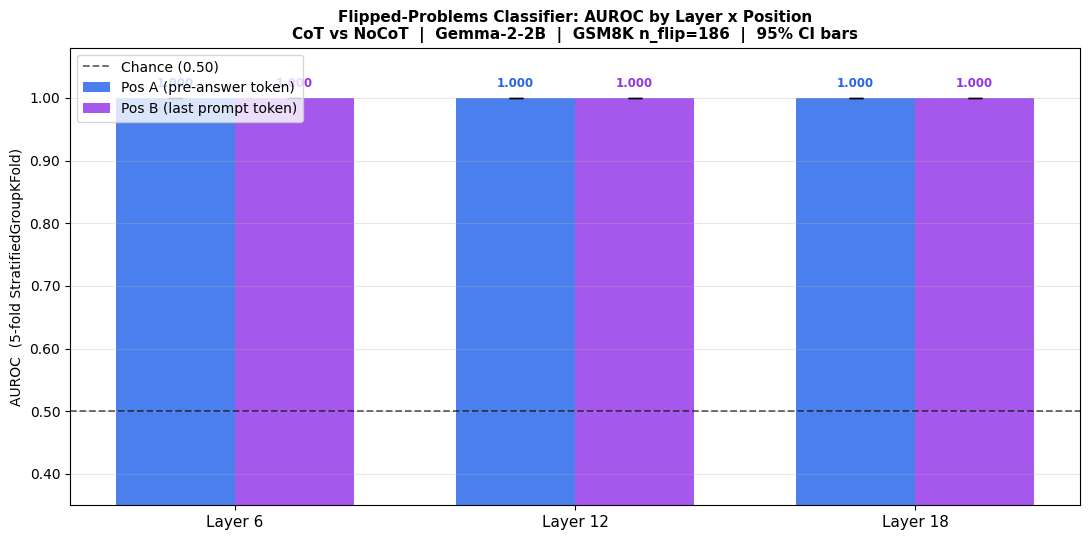

In [10]:
AUROC_GRID_FIG = FIGURES_DIR / 'fig2_auroc_grid.png'


def plot_auroc_grid(df_full, boot_dists, save_path=None):
    """Grouped bar chart: AUROC per layer, split by position, with CI error bars."""
    fig, ax = plt.subplots(figsize=(11, 5.5))

    x     = np.arange(len(LAYERS))
    width = 0.35

    pos_meta = [
        ('pos_a', '#2563EB', 'Pos A (pre-answer token)'),
        ('pos_b', '#9333EA', 'Pos B (last prompt token)'),
    ]

    for i, (pos, color, label) in enumerate(pos_meta):
        sub    = df_full[df_full.position == pos].sort_values('layer')
        vals   = sub['auroc'].values
        ci_lo  = sub['ci_lo'].values
        ci_hi  = sub['ci_hi'].values
        offset = (i - 0.5) * width

        bars = ax.bar(x + offset, vals, width,
                      label=label, color=color, alpha=0.82)

        # 95% CI error bars derived from bootstrap distributions
        ax.errorbar(
            x + offset, vals,
            yerr=[vals - ci_lo, ci_hi - vals],
            fmt='none', color='black', capsize=5, linewidth=1.3,
        )

        # Value labels directly above each bar
        for xi, (v, hi) in enumerate(zip(vals, ci_hi)):
            ax.text(xi + offset, hi + 0.012, f'{v:.3f}',
                    ha='center', va='bottom', fontsize=8.5,
                    fontweight='bold', color=color)

    ax.axhline(0.5, color='black', linestyle='--', linewidth=1.3,
               alpha=0.6, label='Chance (0.50)')

    ax.set_xticks(x)
    ax.set_xticklabels([f'Layer {l}' for l in LAYERS], fontsize=11)
    ax.set_ylabel('AUROC  (5-fold StratifiedGroupKFold)', fontsize=10)
    ax.set_title(
        f'Flipped-Problems Classifier: AUROC by Layer x Position\n'
        f'CoT vs NoCoT  |  Gemma-2-2B  |  GSM8K n_flip={n_flip}  |  95% CI bars',
        fontsize=11, fontweight='bold',
    )
    ax.set_ylim(0.35, 1.08)
    ax.legend(fontsize=10, loc='upper left')
    ax.yaxis.set_major_formatter(mticker.FormatStrFormatter('%.2f'))
    ax.grid(axis='y', alpha=0.3, linewidth=0.7)

    plt.tight_layout()
    if save_path:
        fig.savefig(save_path, dpi=150, bbox_inches='tight')
        print(f'Saved: {save_path}')
    plt.show()
    plt.close(fig)


if AUROC_GRID_FIG.exists():
    print(f'Figure already exists: {AUROC_GRID_FIG}')
    try:
        from IPython.display import Image
        display(Image(str(AUROC_GRID_FIG)))
    except Exception:
        pass
else:
    plot_auroc_grid(df_lr_full, boot_dists, save_path=AUROC_GRID_FIG)

## 8. Figure 3 — PCA Scatter: CoT vs NoCoT on Flipped Problems

Projects the Layer 12, Position A activations of flipped problems to 2D with PCA.
CoT activations are shown in blue, NoCoT in red. Star markers show the class centroids.

**Note:** PCA is a linear projection — visible overlap here does not necessarily mean
the classifier fails (relevant dimensions may lie outside the top-2 PCs). Conversely,
clear visual separation provides intuitive geometric evidence that the residual stream
has encoded condition-specific information.

**Saved:** `figures/fig3_pca_scatter.png`

Saved: /content/drive/MyDrive/experiments/exp4_flipped_problems_classifier/backup/figures/fig3_pca_scatter.png


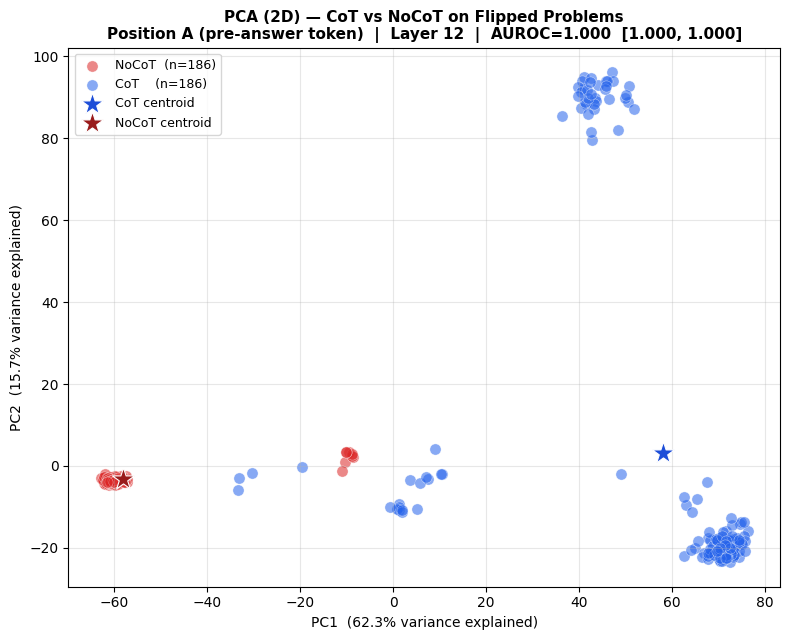

In [11]:
PCA_FIG = FIGURES_DIR / 'fig3_pca_scatter.png'


def plot_pca_scatter(pos, layer, save_path=None):
    """2D PCA scatter of CoT vs NoCoT activations on flipped problems."""
    X = stacked_acts[(pos, layer)]   # (2*n_flip, 2304)

    pca  = PCA(n_components=2, random_state=SEED)
    X_2d = pca.fit_transform(X)
    var  = pca.explained_variance_ratio_

    X_cot  = X_2d[y_flip == 1]
    X_noc  = X_2d[y_flip == 0]

    # Retrieve AUROC for title annotation
    row = df_lr_full[(df_lr_full.position == pos) & (df_lr_full.layer == layer)].iloc[0]

    fig, ax = plt.subplots(figsize=(8, 6.5))

    ax.scatter(X_noc[:, 0], X_noc[:, 1], c='#DC2626', alpha=0.55, s=65,
               label=f'NoCoT  (n={n_flip})', edgecolors='white', linewidths=0.4)
    ax.scatter(X_cot[:, 0], X_cot[:, 1], c='#2563EB', alpha=0.55, s=65,
               label=f'CoT    (n={n_flip})', edgecolors='white', linewidths=0.4)

    # Class centroids
    ax.scatter(*X_cot.mean(axis=0), c='#1D4ED8', marker='*', s=280,
               zorder=5, edgecolors='white', linewidths=0.8, label='CoT centroid')
    ax.scatter(*X_noc.mean(axis=0), c='#991B1B', marker='*', s=280,
               zorder=5, edgecolors='white', linewidths=0.8, label='NoCoT centroid')

    pos_lbl = 'A (pre-answer token)' if pos == 'pos_a' else 'B (last prompt token)'
    ax.set_title(
        f'PCA (2D) — CoT vs NoCoT on Flipped Problems\n'
        f'Position {pos_lbl}  |  Layer {layer}  '
        f'|  AUROC={row.auroc:.3f}  [{row.ci_lo:.3f}, {row.ci_hi:.3f}]',
        fontsize=11, fontweight='bold',
    )
    ax.set_xlabel(f'PC1  ({var[0]:.1%} variance explained)', fontsize=10)
    ax.set_ylabel(f'PC2  ({var[1]:.1%} variance explained)', fontsize=10)
    ax.legend(fontsize=9, loc='best')
    ax.grid(alpha=0.3)

    plt.tight_layout()
    if save_path:
        fig.savefig(save_path, dpi=150, bbox_inches='tight')
        print(f'Saved: {save_path}')
    plt.show()
    plt.close(fig)


if PCA_FIG.exists():
    print(f'Figure already exists: {PCA_FIG}')
    try:
        from IPython.display import Image
        display(Image(str(PCA_FIG)))
    except Exception:
        pass
else:
    plot_pca_scatter(PRIMARY_POS, PRIMARY_LAYER, save_path=PCA_FIG)

## 9. SAE Feature Analysis — 4 sub-cells (conditional: requires Exp 2 cache)

Split into four independently resumable cells so a Colab crash at any point
loses at most one sub-step:

| Sub-cell | What it does | Compute cost |
|---|---|---|
| **9a** | Check Exp 2 availability + load/cache stacked SAE features (2·n_flip, 16 384) | Light |
| **9b** | 5-fold grouped CV on 16k features + bootstrap CI | **Heavy — ~2–10 min** |
| **9c** | Full LR fit for feature ranking + save CSV | **Moderate — ~1–3 min** |
| **9d** | Plot Figure 4 | Light |

**Skipped automatically** if the Exp 2 decomposition cache is absent.

### 9a — Load SAE Features

Fast: loads or caches the stacked `(2·n_flip, 16 384)` feature array.

In [12]:
# ── 9a: Check Exp 2 availability + load/cache stacked SAE features ───────
# Caches the (2*n_flip, 16384) stacked array so 9b and 9c skip the 2x load.

SAE_LR_CACHE   = CACHE_DIR / 'flipped_sae_lr_results.csv'
SAE_CV_CACHE   = CACHE_DIR / 'sae_cv_predictions.npz'
SAE_BOOT_CACHE = CACHE_DIR / 'bootstrap_sae_pos_a.npy'
SAE_TOP_CACHE  = CACHE_DIR / 'flipped_sae_top_features.csv'
SAE_X_CACHE    = CACHE_DIR / 'flipped_sae_X.npy'
SAE_FIG        = FIGURES_DIR / 'fig4_sae_top_features.png'

exp2_feat_cot = EXP2_CACHE / 'decomp_cot_pos_a_features.npy'
exp2_feat_noc = EXP2_CACHE / 'decomp_nocot_pos_a_features.npy'
has_exp2_sae  = exp2_feat_cot.exists() and exp2_feat_noc.exists()

if not has_exp2_sae:
    print('Exp 2 SAE cache not found — sub-cells 9a through 9d will be skipped.')
    print(f'Expected: {exp2_feat_cot}')
    print('Run exp2_sae_decomposition first to enable this section.')
else:
    if SAE_X_CACHE.exists():
        X_sae = np.load(SAE_X_CACHE)
        print(f'Stacked SAE features loaded from cache: {X_sae.shape}')
    else:
        print('Loading SAE feature arrays from Exp 2 cache...')
        feat_cot   = np.load(exp2_feat_cot)    # (400, 16384) float32
        feat_nocot = np.load(exp2_feat_noc)    # (400, 16384) float32
        X_sae = np.vstack([
            feat_cot[flipped_mask],
            feat_nocot[flipped_mask],
        ])  # (2*n_flip, 16384)
        np.save(SAE_X_CACHE, X_sae)
        print(f'Stacked X_sae: {X_sae.shape}  -> saved to {SAE_X_CACHE}')
    print('9a complete.')


Loading SAE feature arrays from Exp 2 cache...
Stacked X_sae: (372, 16384)  -> saved to /content/drive/MyDrive/experiments/exp4_flipped_problems_classifier/backup/cache/flipped_sae_X.npy
9a complete.


### 9b — CV AUROC + Bootstrap on SAE Features

**Heaviest sub-cell.** Saves CV predictions and bootstrap distribution before 9c starts so a crash here does not force a CV re-run.

In [13]:
# ── 9b: 5-fold CV + bootstrap CI on 16k SAE features ─────────────────────
# Heaviest sub-cell. Each result is written to disk before the next step begins.

if not has_exp2_sae:
    print('Skipping 9b.')
else:
    # Load X_sae from 9a cache if not in memory (e.g. kernel was restarted after 9a)
    if 'X_sae' not in dir() or X_sae is None:
        assert SAE_X_CACHE.exists(), 'Run 9a first to create SAE_X_CACHE.'
        X_sae = np.load(SAE_X_CACHE)

    if SAE_LR_CACHE.exists() and SAE_CV_CACHE.exists() and SAE_BOOT_CACHE.exists():
        # All three outputs already on disk — load and skip recomputation
        df_sae_lr            = pd.read_csv(SAE_LR_CACHE)
        npz_cv               = np.load(SAE_CV_CACHE)
        y_true_sae, y_score_sae = npz_cv['y_true'], npz_cv['y_score']
        boot_sae             = np.load(SAE_BOOT_CACHE)
        ci_lo_sae, ci_hi_sae = np.percentile(boot_sae, [2.5, 97.5])
        print('9b results loaded from cache.')
        print(f'  SAE AUROC: {df_sae_lr["auroc"].values[0]:.4f}  '
              f'CI=[{ci_lo_sae:.4f}, {ci_hi_sae:.4f}]')
    else:
        # Step 1 — 5-fold grouped CV (the expensive part)
        print(f'Running 5-fold CV on X_sae {X_sae.shape}  (may take 2-10 min)...')
        auroc_sae, fold_sae, y_true_sae, y_score_sae = run_grouped_cv(
            X_sae, y_flip, groups_flip
        )
        # Save CV predictions before doing anything else (crash recovery point)
        np.savez(SAE_CV_CACHE, y_true=y_true_sae, y_score=y_score_sae)
        print(f'  CV done.  AUROC={auroc_sae:.4f}  folds={[round(v,3) for v in fold_sae]}')
        print(f'  CV predictions saved -> {SAE_CV_CACHE}')

        # Step 2 — bootstrap CI (fast once predictions exist)
        ci_lo_sae, ci_hi_sae, boot_sae = bootstrap_ci(y_true_sae, y_score_sae)
        np.save(SAE_BOOT_CACHE, boot_sae)
        print(f'  Bootstrap done.  95% CI=[{ci_lo_sae:.4f}, {ci_hi_sae:.4f}]')
        print(f'  Bootstrap distribution saved -> {SAE_BOOT_CACHE}')

        # Step 3 — save summary CSV
        df_sae_lr = pd.DataFrame([{
            'representation': 'SAE_features_16k',
            'position':       'pos_a',
            'layer':          SAE_LAYER,
            'auroc':          round(auroc_sae, 4),
            'ci_lo':          round(ci_lo_sae, 4),
            'ci_hi':          round(ci_hi_sae, 4),
            'n_features':     N_SAE_FEATS,
        }])
        df_sae_lr.to_csv(SAE_LR_CACHE, index=False)
        print(f'  SAE LR results saved -> {SAE_LR_CACHE}')

    # Quick comparison with raw residual at same (pos_a, layer 12)
    if 'df_lr_full' in dir() and df_lr_full is not None:
        raw_row = df_lr_full[
            (df_lr_full.position == 'pos_a') & (df_lr_full.layer == SAE_LAYER)
        ].iloc[0]
        sae_v = df_sae_lr['auroc'].values[0]
        print(f'\n  SAE features (16k)  AUROC={sae_v:.4f}  '
              f'[{df_sae_lr["ci_lo"].values[0]:.4f}, {df_sae_lr["ci_hi"].values[0]:.4f}]')
        print(f'  Raw residual (2304) AUROC={raw_row.auroc:.4f}  '
              f'[{raw_row.ci_lo:.4f}, {raw_row.ci_hi:.4f}]')
    print('9b complete.')


Running 5-fold CV on X_sae (372, 16384)  (may take 2-10 min)...
  CV done.  AUROC=1.0000  folds=[np.float64(1.0), np.float64(1.0), np.float64(1.0), np.float64(1.0), np.float64(1.0)]
  CV predictions saved -> /content/drive/MyDrive/experiments/exp4_flipped_problems_classifier/backup/cache/sae_cv_predictions.npz
  Bootstrap done.  95% CI=[1.0000, 1.0000]
  Bootstrap distribution saved -> /content/drive/MyDrive/experiments/exp4_flipped_problems_classifier/backup/cache/bootstrap_sae_pos_a.npy
  SAE LR results saved -> /content/drive/MyDrive/experiments/exp4_flipped_problems_classifier/backup/cache/flipped_sae_lr_results.csv

  SAE features (16k)  AUROC=1.0000  [1.0000, 1.0000]
  Raw residual (2304) AUROC=1.0000  [1.0000, 1.0000]
9b complete.


### 9c — Feature Ranking LR

Fits one LR on all `2·n_flip` samples to rank the top 20 most discriminative SAE features. Saved to `cache/flipped_sae_top_features.csv`.

In [14]:
# ── 9c: Full LR fit for feature ranking ───────────────────────────────────
# Fits one LR on ALL 2*n_flip samples in 16k-feature space to get coefficient
# magnitudes for ranking. Saved separately from 9b so a crash here does not
# force a CV re-run.

if not has_exp2_sae:
    print('Skipping 9c.')
else:
    if SAE_TOP_CACHE.exists():
        df_sae_top = pd.read_csv(SAE_TOP_CACHE)
        print(f'Top features loaded from cache ({len(df_sae_top)} rows).')
    else:
        # Load X_sae from cache if not in memory
        if 'X_sae' not in dir() or X_sae is None:
            assert SAE_X_CACHE.exists(), 'Run 9a first.'
            X_sae = np.load(SAE_X_CACHE)

        print(f'Fitting ranking LR on X_sae {X_sae.shape}  (may take 1-3 min)...')
        lr_sae = LogisticRegression(
            C=LR_C, class_weight='balanced',
            max_iter=3000, solver='lbfgs', random_state=SEED,
        )
        lr_sae.fit(X_sae, y_flip)
        print('  Fit complete.')

        coefs   = lr_sae.coef_[0]                       # (16384,)
        top_idx = np.argsort(np.abs(coefs))[::-1][:20]

        X_cot_sae = X_sae[:n_flip]
        X_noc_sae = X_sae[n_flip:]

        df_sae_top = pd.DataFrame({
            'rank':             range(1, 21),
            'feature_id':       top_idx,
            'coef':             coefs[top_idx].round(6),
            'abs_coef':         np.abs(coefs[top_idx]).round(6),
            'mean_act_cot':     X_cot_sae[:, top_idx].mean(axis=0).round(4),
            'mean_act_nocot':   X_noc_sae[:, top_idx].mean(axis=0).round(4),
            'pct_active_cot':   (X_cot_sae[:, top_idx] > 0).mean(axis=0).round(4),
            'pct_active_nocot': (X_noc_sae[:, top_idx] > 0).mean(axis=0).round(4),
        })
        df_sae_top['delta_mean_act'] = (
            df_sae_top['mean_act_cot'] - df_sae_top['mean_act_nocot']
        ).round(4)
        df_sae_top.to_csv(SAE_TOP_CACHE, index=False)
        print(f'  Top features saved -> {SAE_TOP_CACHE}')

    print('\nTop 20 SAE features (CoT vs NoCoT discriminators on flipped problems):')
    print(df_sae_top[[
        'rank', 'feature_id', 'coef',
        'pct_active_cot', 'pct_active_nocot', 'delta_mean_act',
    ]].to_string(index=False))
    print('9c complete.')


Fitting ranking LR on X_sae (372, 16384)  (may take 1-3 min)...
  Fit complete.
  Top features saved -> /content/drive/MyDrive/experiments/exp4_flipped_problems_classifier/backup/cache/flipped_sae_top_features.csv

Top 20 SAE features (CoT vs NoCoT discriminators on flipped problems):
 rank  feature_id      coef  pct_active_cot  pct_active_nocot  delta_mean_act
    1        5206 -0.087549          0.0000            0.9570      -21.461700
    2       12440 -0.076489          0.0753            0.0430       -0.699500
    3       11092  0.066992          0.6989            0.0000       22.680700
    4        4063  0.066076          1.0000            1.0000        9.207100
    5       14348 -0.061390          0.1022            1.0000      -37.811100
    6       10967  0.057896          0.9247            0.9839        3.259600
    7        6163 -0.056037          0.1022            1.0000      -21.053699
    8       12342  0.054692          0.9624            0.9570        5.978400
    9       

### 9d — Figure 4: SAE Top-Feature Chart

Light: loads from cache and plots. Saved to `figures/fig4_sae_top_features.png`.

Saved: /content/drive/MyDrive/experiments/exp4_flipped_problems_classifier/backup/figures/fig4_sae_top_features.png


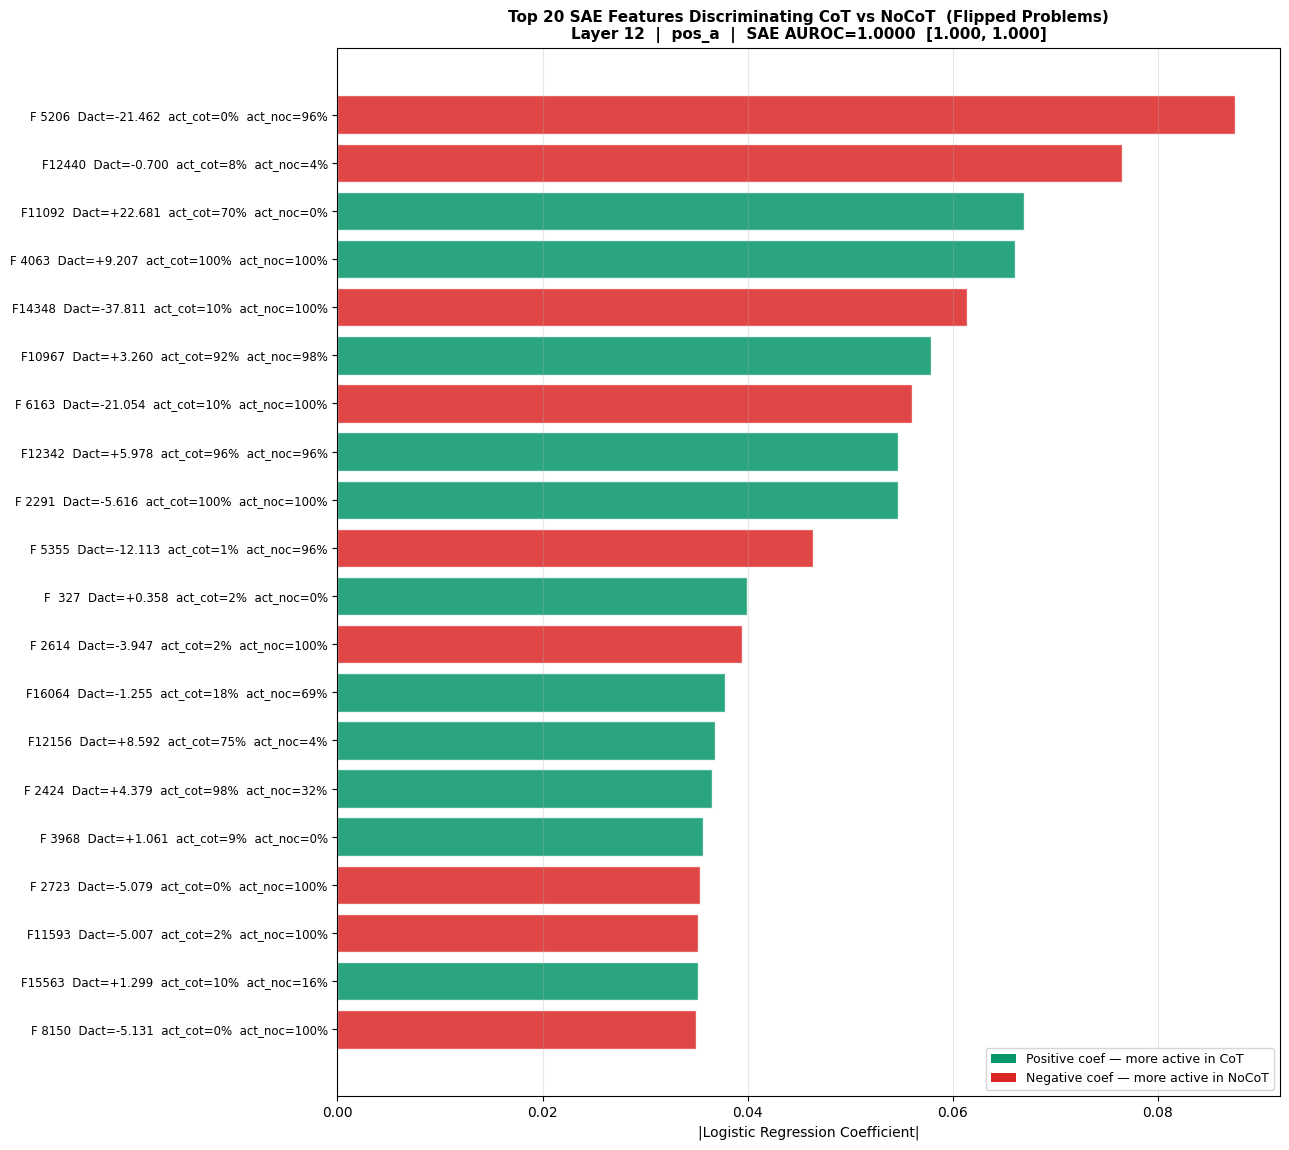

9d complete.


In [15]:
# ── 9d: Figure 4 — top SAE feature importance chart ──────────────────────

if not has_exp2_sae:
    print('Skipping 9d.')
else:
    # Load from cache if not already in memory
    if 'df_sae_top' not in dir() or df_sae_top is None:
        assert SAE_TOP_CACHE.exists(), 'Run 9c first.'
        df_sae_top = pd.read_csv(SAE_TOP_CACHE)
    if 'df_sae_lr' not in dir() or df_sae_lr is None:
        assert SAE_LR_CACHE.exists(), 'Run 9b first.'
        df_sae_lr = pd.read_csv(SAE_LR_CACHE)

    if SAE_FIG.exists():
        print(f'Figure already exists: {SAE_FIG}')
        try:
            from IPython.display import Image
            display(Image(str(SAE_FIG)))
        except Exception:
            pass
    else:
        df_top  = df_sae_top.head(20)
        colors  = ['#059669' if c > 0 else '#DC2626' for c in df_top['coef']]
        y_pos   = list(range(len(df_top) - 1, -1, -1))
        labels  = [
            f'F{int(r.feature_id):5d}  Dact={r.delta_mean_act:+.3f}  '
            f'act_cot={r.pct_active_cot:.0%}  act_noc={r.pct_active_nocot:.0%}'
            for _, r in df_top.iterrows()
        ]

        fig_h = max(0.48 * len(df_top) + 2, 7)
        fig, ax = plt.subplots(figsize=(13, fig_h))
        ax.barh(y_pos, df_top['abs_coef'].values,
                color=colors, alpha=0.85, edgecolor='white')
        ax.set_yticks(y_pos)
        ax.set_yticklabels(labels, fontsize=8.5)
        ax.set_xlabel('|Logistic Regression Coefficient|', fontsize=10)

        sae_auroc = df_sae_lr['auroc'].values[0]
        sae_ci_lo = df_sae_lr['ci_lo'].values[0]
        sae_ci_hi = df_sae_lr['ci_hi'].values[0]
        ax.set_title(
            f'Top 20 SAE Features Discriminating CoT vs NoCoT  (Flipped Problems)\n'
            f'Layer {SAE_LAYER}  |  pos_a  |  SAE AUROC={sae_auroc:.4f}'
            f'  [{sae_ci_lo:.3f}, {sae_ci_hi:.3f}]',
            fontsize=11, fontweight='bold',
        )
        legend_elems = [
            Patch(facecolor='#059669', label='Positive coef — more active in CoT'),
            Patch(facecolor='#DC2626', label='Negative coef — more active in NoCoT'),
        ]
        ax.legend(handles=legend_elems, fontsize=9)
        ax.grid(axis='x', alpha=0.3)

        plt.tight_layout()
        fig.savefig(SAE_FIG, dpi=150, bbox_inches='tight')
        print(f'Saved: {SAE_FIG}')
        plt.show()
        plt.close(fig)
    print('9d complete.')


## 10. Summary — Key Numbers & JSON Cache

Aggregates all primary results into a single JSON file. This is the canonical
source of truth for Exp 4 numbers when referenced from other notebooks or the
thesis write-up.

**Saved:** `cache/flipped_summary.json`

In [16]:
SUMMARY_CACHE = CACHE_DIR / 'flipped_summary.json'

primary_row = df_lr_full[
    (df_lr_full.position == PRIMARY_POS) &
    (df_lr_full.layer    == PRIMARY_LAYER)
].iloc[0]

summary = {
    'experiment':  'exp4_flipped_problems_classifier',
    'model':       'Gemma-2-2B-IT (google/gemma-2-2b-it)',
    'dataset':     'GSM8K test  n=400  seed=42',
    'n_total':     int(len(flipped_mask)),
    'n_flipped':   int(n_flip),
    'pct_flipped': round(float(n_flip / len(flipped_mask)), 4),
    'primary_metric': {
        'description': 'CoT vs NoCoT AUROC on flipped problems',
        'position':    PRIMARY_POS,
        'layer':       PRIMARY_LAYER,
        'auroc':       round(float(primary_row['auroc']), 4),
        'auroc_std':   round(float(primary_row['auroc_std']), 4),
        'ci_lo_95':    round(float(primary_row['ci_lo']), 4),
        'ci_hi_95':    round(float(primary_row['ci_hi']), 4),
        'p_vs_chance': round(float(primary_row['p_vs_chance']), 4),
        'n_boot':      N_BOOT,
    },
    'all_results': df_lr_full.to_dict(orient='records'),
    'figures': [
        'figures/fig1_roc_curve.png',
        'figures/fig2_auroc_grid.png',
        'figures/fig3_pca_scatter.png',
        'figures/fig4_sae_top_features.png  (if Exp 2 available)',
    ],
}

# Add SAE results if available
if has_exp2_sae and SAE_LR_CACHE.exists():
    sae_row = pd.read_csv(SAE_LR_CACHE).iloc[0]
    summary['sae_features'] = {
        'auroc': round(float(sae_row['auroc']), 4),
        'ci_lo': round(float(sae_row['ci_lo']), 4),
        'ci_hi': round(float(sae_row['ci_hi']), 4),
    }

with open(SUMMARY_CACHE, 'w') as fh:
    json.dump(summary, fh, indent=2)
print(f'Summary saved -> {SUMMARY_CACHE}')

# ── Final results printout ────────────────────────────────────────────────
print()
print('=' * 70)
print('  EXP 4 FINAL RESULTS — FLIPPED-PROBLEMS CLASSIFIER')
print('=' * 70)
print(f'  Dataset:      GSM8K test, n=400, seed=42')
print(f'  Flipped:      {n_flip} / {len(flipped_mask)} problems  '
      f'({n_flip/len(flipped_mask):.1%})')
print(f'  Classifier:   L2 LogReg  C={LR_C}  {LR_FOLDS}-fold StratifiedGroupKFold')
print(f'  Bootstrap CI: n_boot={N_BOOT}, percentile method')
print()
print(f'  {"Position":<10} {"Layer":>5}  {"AUROC":>7}  {"95% CI":>20}  {"p>0.5":>8}')
print('  ' + '-' * 58)
for _, row in df_lr_full.sort_values(['position', 'layer']).iterrows():
    ci_str = f'[{row.ci_lo:.4f}, {row.ci_hi:.4f}]'
    mkr    = ' <-- PRIMARY' if (row.position == PRIMARY_POS
                                and row.layer == PRIMARY_LAYER) else ''
    print(f'  {row.position:<10} {row.layer:>5}  {row.auroc:>7.4f}  '
          f'{ci_str:>20}  {1-row.p_vs_chance:>8.4f}{mkr}')
print('=' * 70)

if has_exp2_sae and SAE_LR_CACHE.exists():
    sae_row = pd.read_csv(SAE_LR_CACHE).iloc[0]
    print(f'\n  SAE features (16k)  L12  {sae_row.auroc:.4f}  '
          f'[{sae_row.ci_lo:.4f}, {sae_row.ci_hi:.4f}]')

Summary saved -> /content/drive/MyDrive/experiments/exp4_flipped_problems_classifier/backup/cache/flipped_summary.json

  EXP 4 FINAL RESULTS — FLIPPED-PROBLEMS CLASSIFIER
  Dataset:      GSM8K test, n=400, seed=42
  Flipped:      186 / 400 problems  (46.5%)
  Classifier:   L2 LogReg  C=0.1  5-fold StratifiedGroupKFold
  Bootstrap CI: n_boot=1000, percentile method

  Position   Layer    AUROC                95% CI     p>0.5
  ----------------------------------------------------------
  pos_a          6   1.0000      [1.0000, 1.0000]    1.0000
  pos_a         12   1.0000      [1.0000, 1.0000]    1.0000 <-- PRIMARY
  pos_a         18   1.0000      [1.0000, 1.0000]    1.0000
  pos_b          6   1.0000      [1.0000, 1.0000]    1.0000
  pos_b         12   1.0000      [1.0000, 1.0000]    1.0000
  pos_b         18   1.0000      [1.0000, 1.0000]    1.0000

  SAE features (16k)  L12  1.0000  [1.0000, 1.0000]


## Results

### Primary Numbers

| Metric | Value |
|---|---|
| n_flipped (CoT correct, NoCoT wrong) | **186 / 400 (46.5%)** |
| AUROC — pos_a, Layer 6 | 1.0000  [1.000, 1.000] |
| AUROC — pos_a, Layer 12 | 1.0000  [1.000, 1.000] |
| AUROC — pos_a, Layer 18 | 1.0000  [1.000, 1.000] |
| AUROC — pos_b, Layer 6 | 1.0000  [1.000, 1.000] |
| AUROC — pos_b, Layer 12 | 1.0000  [1.000, 1.000] |
| AUROC — pos_b, Layer 18 | 1.0000  [1.000, 1.000] |
| SAE features AUROC (pos_a, L12, 16k features) | 1.0000  [1.000, 1.000] |
| CoT score range (all combos) | [0.935, 1.000] |
| NoCoT score range (all combos) | [0.000, 0.088] |
| Score distribution overlap | **None** in any combo |

---

### Answering the Pre-Registered Questions

**1. Does pos_a AUROC ≫ 0.5?**
Yes — AUROC = 1.000 at every layer. The CoT and NoCoT residual streams are
perfectly linearly separable on the flipped subset. However, perfect separation
at *pos_b* (see Q2) makes it impossible to attribute this to CoT reasoning.

**2. Is pos_b AUROC ≈ 0.5?**
**No — this is the critical failure.** pos_b AUROC = 1.000 at all layers, with
no score overlap (CoT scores: [0.935, 0.998]; NoCoT scores: [0.006, 0.088] at
the weakest layer). pos_b is the last prompt token captured *before generation
begins*. At that position the only difference between conditions is the system
prompt instruction ("think step by step" vs "answer directly"). Perfect
separation at pos_b means the classifier is detecting the **prompt condition**,
not any computation that takes place during the CoT chain.

**3. Does layer 12 outperform layers 6 and 18?**
Not assessable — all six layer × position combinations hit the ceiling at 1.000.
The ceiling prevents any layer-wise comparison.

**4. Does SAE-feature AUROC match raw-residual AUROC?**
Yes — SAE features (16k) also achieve AUROC = 1.000. The top discriminating
features are **condition markers**, not reasoning-quality features:

| SAE Feature | pct\_active CoT | pct\_active NoCoT | Role |
|---|---|---|---|
| F5206  (rank 1) | 0.0% | 95.7% | NoCoT mode indicator |
| F11092 (rank 3) | 69.9% | 0.0% | CoT mode indicator |
| F14348 (rank 5) | 10.2% | 100.0% | NoCoT mode indicator |
| F6163  (rank 7) | 10.2% | 100.0% | NoCoT mode indicator |

These features fire based on which system prompt was used; they are present even
in problems that CoT gets wrong, confirming they encode prompting mode rather
than reasoning success.

**5. How does this compare to Exp 1?**
Exp 1 achieves AUROC ~ 0.73–0.80 classifying *correct vs incorrect* within a
single condition. Exp 4 achieves AUROC = 1.000 classifying *CoT vs NoCoT*.
The comparison is not meaningful: Exp 1 faces a hard problem (predicting
correctness from activations, same prompt), whereas Exp 4 faces a trivial
problem (distinguishing two different prompts from activations).

---

### Interpretation

The experiment confirms that CoT and NoCoT residual streams are perfectly
linearly separable on flipped problems — but the separation is driven by a
**prompt-level confound** rather than by reasoning computation. Because the two
conditions use different system prompts, the model encodes "which mode am I in?"
as a strong linear signal at every layer and position, including positions
captured before any reasoning tokens are generated (pos_b). The flipped-problem
restriction successfully controls for problem difficulty, but does not remove
the prompt-condition confound.

The top SAE features are binary condition markers with near-zero activation in
one condition and near-full activation in the other. None of the top-20 features
can be interpreted as "this problem is about to be solved correctly" — they are
best read as "this forward pass is in CoT mode / NoCoT mode."

**What Exp 4 does and does not establish:**
- **Does establish:** CoT and NoCoT produce distinct residual stream states that
  are trivially separable by a linear probe. This is expected and consistent with
  the mechanistic finding from H1 (Exp 2) that specific SAE features are
  differentially activated under the two conditions.
- **Does not establish:** That the *reasoning computation* (the step-by-step
  chain itself) creates a qualitatively different representation. To test that,
  one would need to either (a) use identical prompts and vary only the presence
  of reasoning in the generated prefix, or (b) probe *within* the CoT condition
  for whether activations predict correctness on the flipped subset specifically
  — which is the question addressed in Exp 1 restricted to this subset.

---

### Next Steps

- **Confound-controlled probe:** Re-run the classification using the *residual*
  after projecting out the mean CoT–NoCoT activation difference (computed on
  non-flipped problems). If AUROC remains above chance on flipped problems, it
  would indicate condition-independent, problem-specific signal.
- **Within-CoT analysis:** On the 186 flipped problems, compare the CoT pos_a
  activations against the NoCoT activations from *non-flipped* problems where
  NoCoT also succeeds. This decouples "CoT mode" from "problem being solved
  correctly."
- `exp5_mode_switch_control` — tests whether feature induction triggers CoT-style
  output on NoCoT problems (directly follows from the mode-marker finding above).
